# Taller de Análisis Estadístico con Python para Big Data

## Objetivos
- Aplicar los conceptos estadísticos vistos en clase a un conjunto de datos real
- Implementar medidas de tendencia central, dispersión y asociación usando Python
- Interpretar resultados en el contexto de Big Data

## Conjunto de Datos
Para esta actividad utilizaremos un dataset de ventas en línea de una tienda de comercio electrónico. El conjunto contiene información sobre transacciones, clientes, productos y comportamiento de navegación.

1. Cargue el Archivo: S6_ecommerce_data.csv
2. Importe la librería pandas
3. Lea los datos en un dataframe



In [1]:
import pandas as pd
df = pd.read_csv('S6_ecommerce_data.csv')
df.head()


,transaction_id,customer_id,product,category,price,quantity,discount_applied,page_views_before_purchase,time_spent_on_site_mins,days_since_last_purchase,is_returning_customer,device,ab_test_group
0,1,103,Camera,Electronics,32.431644,2,1,4,14.074097,5.194277,1,Tablet,A
1,2,436,Mouse,Gaming,87.439692,4,0,5,13.502536,24.694305,1,Mobile,A
2,3,861,Keyboard,Gaming,123.933947,2,0,5,0.860749,11.185982,0,Tablet,B
3,4,271,Laptop,Gaming,59.235915,3,0,2,24.420370,34.656201,1,Mobile,A
4,5,107,Printer,Electronics,70.655241,3,0,10,43.039109,6.773373,0,Mobile,A


## Actividades

### Parte 1: Exploración Inicial y Medidas de Tendencia Central

1. Identifique variables, determine su tipo (cualitativas/cuantitativas)

Sugerencia: Busque cómo generar una lista de variables de tipo numérico a partir de un dataframe, y cómo generar una lista de variables de tipo objeto


In [7]:
numeric_vars = df.select_dtypes(include=['number'])
object_vars = df.select_dtypes(include=['object'])

print("Variables Numéricas:")
print(numeric_vars.columns)

print("\nVariables Categóricas (Tipo Objeto):")
print(object_vars.columns)

Variables Numéricas:
Index(['transaction_id', 'customer_id', 'price', 'quantity',
       'discount_applied', 'page_views_before_purchase',
       'time_spent_on_site_mins', 'days_since_last_purchase',
       'is_returning_customer'],
      dtype='object')

Variables Categóricas (Tipo Objeto):
Index(['product', 'category', 'device', 'ab_test_group'], dtype='object')


2. Halle el total de ventas usando cantidad y precio unitario. Añádalo a su dataframe para posterior análisis

In [8]:
df['total_de_ventas'] = df['quantity']*df['price']
df.head()

,transaction_id,customer_id,product,category,price,quantity,discount_applied,page_views_before_purchase,time_spent_on_site_mins,days_since_last_purchase,is_returning_customer,device,ab_test_group,total_de_ventas
0,1,103,Camera,Electronics,32.431644,2,1,4,14.074097,5.194277,1,Tablet,A,64.863288
1,2,436,Mouse,Gaming,87.439692,4,0,5,13.502536,24.694305,1,Mobile,A,349.758768
2,3,861,Keyboard,Gaming,123.933947,2,0,5,0.860749,11.185982,0,Tablet,B,247.867894
3,4,271,Laptop,Gaming,59.235915,3,0,2,24.420370,34.656201,1,Mobile,A,177.707745
4,5,107,Printer,Electronics,70.655241,3,0,10,43.039109,6.773373,0,Mobile,A,211.965723


3. Calcule media, mediana y moda para las variables numéricas

Recuerde: usar función describe()


In [11]:
print("Estadísticas descriptivas para variables numéricas:")
print(numeric_vars.describe())

print("\nModa para variables numéricas:")
for col in numeric_vars.columns:
    mode_val = numeric_vars[col].mode()
    print(f"  {col}: {mode_val.tolist()}")

print("\nMedia para variables numéricas:")
print(numeric_vars.mean())

print("\nMediana para variables numéricas:")
print(numeric_vars.median())

Estadísticas descriptivas para variables numéricas:
       transaction_id   customer_id         price      quantity  \
count     10000.00000  10000.000000  10000.000000  10000.000000   
mean       5000.50000    504.470600     99.815455      3.019200   
std        2886.89568    289.724434     44.558331      1.439388   
min           1.00000      1.000000      7.464581      1.000000   
25%        2500.75000    251.000000     67.236578      2.000000   
50%        5000.50000    506.500000     93.466405      3.000000   
75%        7500.25000    758.000000    124.848525      4.000000   
max       10000.00000   1000.000000    411.713789     10.000000   

       discount_applied  page_views_before_purchase  time_spent_on_site_mins  \
count      10000.000000                10000.000000             10000.000000   
mean           0.298500                    5.024300                15.298796   
std            0.457623                    3.153237                15.035735   
min            0.000000 

4 Identifique Variables Categóricas más importantes. ¿Qué medida de tendencia central usamos para analizar variables categórica? Utilicela para las variables categóricas

In [13]:
print("Variables Categóricas:")
print(object_vars.columns)

# se utiliza la moda para las variables categoricas
print("\nModa para variables categóricas:")
for col in object_vars.columns:
    mode_val = df[col].mode()
    print(f"  {col}: {mode_val.tolist()}")

Variables Categóricas:
Index(['product', 'category', 'device', 'ab_test_group'], dtype='object')

Moda para variables categóricas:
  product: ['Camera']
  category: ['Accessories']
  device: ['Mobile']
  ab_test_group: ['B']


5. Analice las diferencias entre estas medias y mediana y su significado en el contexto

In [19]:
print("\nAnálisis de la diferencia absoluta entre Media y Mediana:")
for col in numeric_vars.columns:
    mean_val = numeric_vars[col].mean()
    median_val = numeric_vars[col].median()
    difference = abs(mean_val - median_val)
    print(f"  {col}: Media = {mean_val:.2f}, Mediana = {median_val:.2f}, Diferencia Absoluta = {difference:.2f}")

print("\nInterpretación:\n- Una diferencia pequeña sugiere una distribución más simétrica.\n- Una diferencia grande (especialmente si la media > mediana) sugiere un sesgo positivo o valores atípicos altos.\n- Una diferencia grande (especialmente si la media < mediana) sugiere un sesgo negativo o valores atípicos bajos.")


Análisis de la diferencia absoluta entre Media y Mediana:
  transaction_id: Media = 5000.50, Mediana = 5000.50, Diferencia Absoluta = 0.00
  customer_id: Media = 504.47, Mediana = 506.50, Diferencia Absoluta = 2.03
  price: Media = 99.82, Mediana = 93.47, Diferencia Absoluta = 6.35
  quantity: Media = 3.02, Mediana = 3.00, Diferencia Absoluta = 0.02
  discount_applied: Media = 0.30, Mediana = 0.00, Diferencia Absoluta = 0.30
  page_views_before_purchase: Media = 5.02, Mediana = 5.00, Diferencia Absoluta = 0.02
  time_spent_on_site_mins: Media = 15.30, Mediana = 10.73, Diferencia Absoluta = 4.57
  days_since_last_purchase: Media = 20.00, Mediana = 16.75, Diferencia Absoluta = 3.25
  is_returning_customer: Media = 0.59, Mediana = 1.00, Diferencia Absoluta = 0.41

Interpretación:
- Una diferencia pequeña sugiere una distribución más simétrica.
- Una diferencia grande (especialmente si la media > mediana) sugiere un sesgo positivo o valores atípicos altos.
- Una diferencia grande (especia


### Parte 2: Análisis de Dispersión y Distribuciones

1. Calcule rango, cuartiles y rango intercuartil para variables clave


In [20]:
print("\nAnálisis de Rango, Cuartiles y Rango Intercuartil para variables numéricas:")
for col in numeric_vars.columns:
    min_val = numeric_vars[col].min()
    max_val = numeric_vars[col].max()
    range_val = max_val - min_val
    q1 = numeric_vars[col].quantile(0.25)
    q2 = numeric_vars[col].median()  # Q2 is the median
    q3 = numeric_vars[col].quantile(0.75)
    iqr = q3 - q1

    print(f"\n  Variable: {col}")
    print(f"    Mínimo: {min_val:.2f}")
    print(f"    Máximo: {max_val:.2f}")
    print(f"    Rango: {range_val:.2f}")
    print(f"    Q1 (25%): {q1:.2f}")
    print(f"    Q2 (50% - Mediana): {q2:.2f}")
    print(f"    Q3 (75%): {q3:.2f}")
    print(f"    Rango Intercuartil (IQR): {iqr:.2f}")


Análisis de Rango, Cuartiles y Rango Intercuartil para variables numéricas:

  Variable: transaction_id
    Mínimo: 1.00
    Máximo: 10000.00
    Rango: 9999.00
    Q1 (25%): 2500.75
    Q2 (50% - Mediana): 5000.50
    Q3 (75%): 7500.25
    Rango Intercuartil (IQR): 4999.50

  Variable: customer_id
    Mínimo: 1.00
    Máximo: 1000.00
    Rango: 999.00
    Q1 (25%): 251.00
    Q2 (50% - Mediana): 506.50
    Q3 (75%): 758.00
    Rango Intercuartil (IQR): 507.00

  Variable: price
    Mínimo: 7.46
    Máximo: 411.71
    Rango: 404.25
    Q1 (25%): 67.24
    Q2 (50% - Mediana): 93.47
    Q3 (75%): 124.85
    Rango Intercuartil (IQR): 57.61

  Variable: quantity
    Mínimo: 1.00
    Máximo: 10.00
    Rango: 9.00
    Q1 (25%): 2.00
    Q2 (50% - Mediana): 3.00
    Q3 (75%): 4.00
    Rango Intercuartil (IQR): 2.00

  Variable: discount_applied
    Mínimo: 0.00
    Máximo: 1.00
    Rango: 1.00
    Q1 (25%): 0.00
    Q2 (50% - Mediana): 0.00
    Q3 (75%): 1.00
    Rango Intercuartil (IQR): 1.

2. Determine la varianza y desviación estándar


In [21]:
print("\nVarianza para variables numéricas:")
print(numeric_vars.var())

print("\nDesviación estándar para variables numéricas:")
print(numeric_vars.std())


Varianza para variables numéricas:
transaction_id                8.334167e+06
customer_id                   8.394025e+04
price                         1.985445e+03
quantity                      2.071839e+00
discount_applied              2.094187e-01
page_views_before_purchase    9.942904e+00
time_spent_on_site_mins       2.260733e+02
days_since_last_purchase      1.996382e+02
is_returning_customer         2.414309e-01
dtype: float64

Desviación estándar para variables numéricas:
transaction_id                2886.895680
customer_id                    289.724434
price                           44.558331
quantity                         1.439388
discount_applied                 0.457623
page_views_before_purchase       3.153237
time_spent_on_site_mins         15.035735
days_since_last_purchase        14.129339
is_returning_customer            0.491356
dtype: float64


3. Calcule z-scores para identificar valores atípicos


In [23]:
import scipy.stats as stats

print("\nCalculando Z-scores para identificar valores atípicos:")
for col in numeric_vars.columns:
    # Calcular los z-scores para cada columna numérica
    df[f'zscore_{col}'] = stats.zscore(df[col])

    # Identificar valores atípicos
    outliers = df[(df[f'zscore_{col}'] > 3) | (df[f'zscore_{col}'] < -3)]

    print(f"\n  Variable: {col}")
    print(f"    Primeros 5 Z-scores: {df[f'zscore_{col}'].head().tolist()}")
    print(f"    Número de valores atípicos (Z-score > 3 o < -3): {len(outliers)}")
    if not outliers.empty:
        print("    Ejemplo de valores atípicos:\n", outliers[[col, f'zscore_{col}']].head())

print("\nInterpretación: Los Z-scores nos ayudan a entender la posición relativa de cada dato respecto a la media y la desviación estándar de su columna. Valores con un Z-score mayor a 2 o 3 (o menor a -2 o -3) son a menudo considerados valores atípicos, sugiriendo que son inusualmente altos o bajos en comparación con el resto de los datos.")


Calculando Z-scores para identificar valores atípicos:

  Variable: transaction_id
    Primeros 5 Z-scores: [-1.7318776111475085, -1.7315312009842627, -1.731184790821017, -1.7308383806577712, -1.7304919704945252]
    Número de valores atípicos (Z-score > 3 o < -3): 0

  Variable: customer_id
    Primeros 5 Z-scores: [-1.3857673987750831, -0.23634190213323017, 1.2306425905778435, -0.8058770581269411, -1.3719604859025083]
    Número de valores atípicos (Z-score > 3 o < -3): 0

  Variable: price
    Primeros 5 Z-scores: [-1.5123362781448348, -0.27775685304184544, 0.5413061408194785, -0.9107515562552236, -0.6544606019419636]
    Número de valores atípicos (Z-score > 3 o < -3): 93
    Ejemplo de valores atípicos:
           price  zscore_price
308  267.156617      3.755741
346  256.343863      3.513063
399  241.742763      3.185362
402  315.239367      4.834891
475  238.136163      3.104417

  Variable: quantity
    Primeros 5 Z-scores: [-0.7081139931890652, 0.6814346590657722, -0.70811399

4. Visualice las distribuciones de frecuencia mediante histogramas

Utilice  `sns.histplot(df[col], kde=True)` para graficar histograma



Visualizando distribuciones de frecuencia con histogramas:


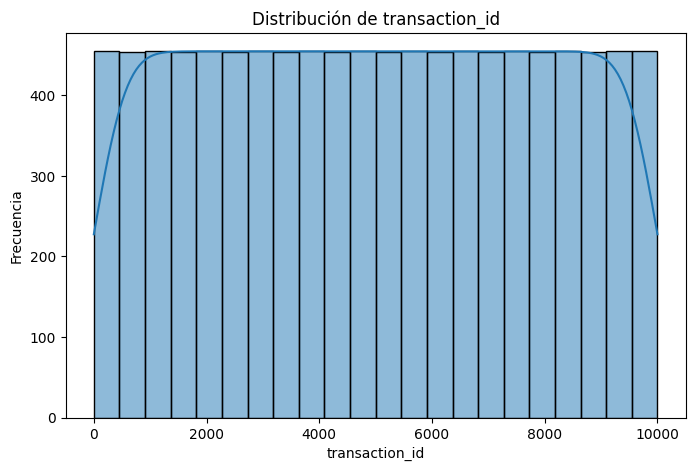

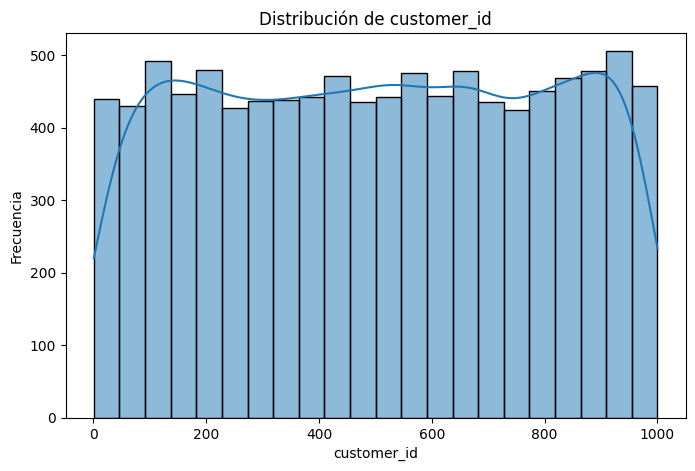

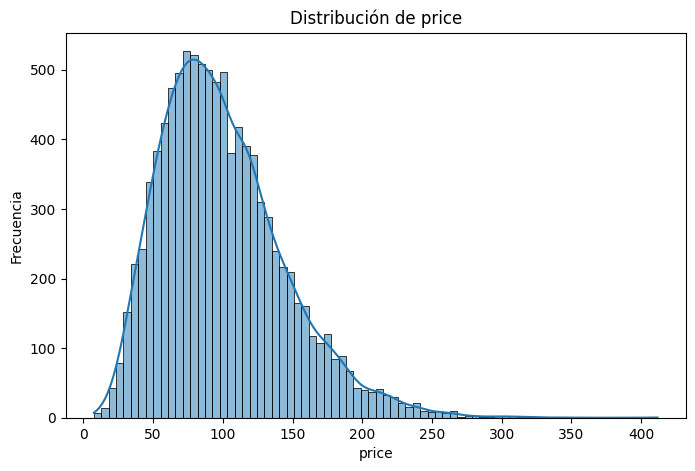

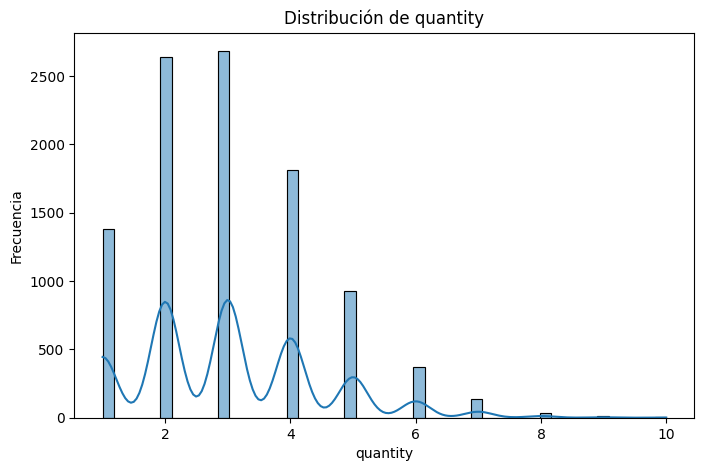

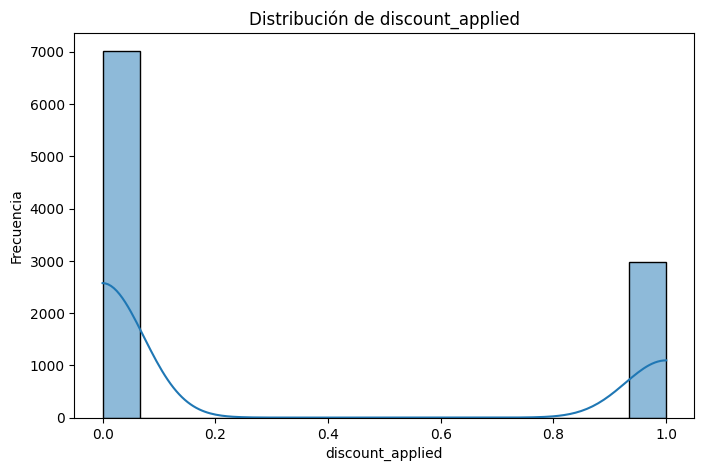

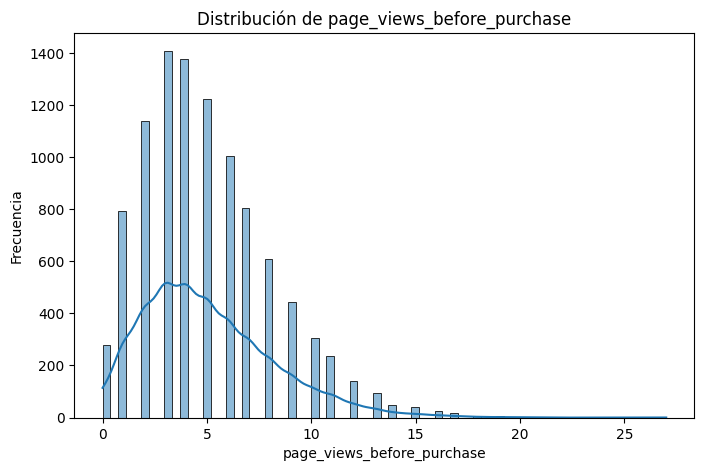

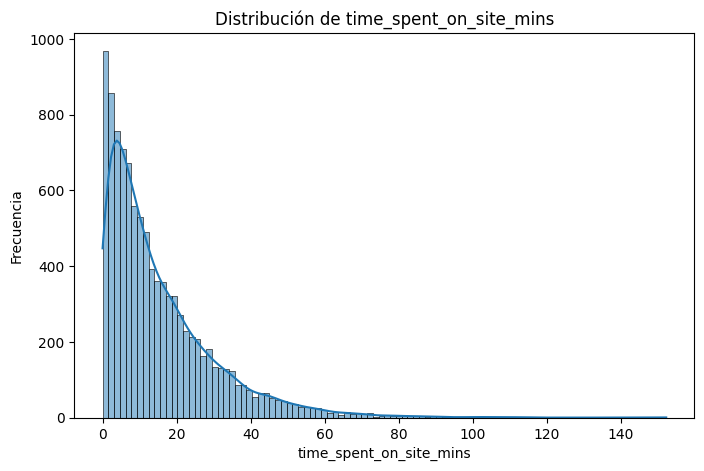

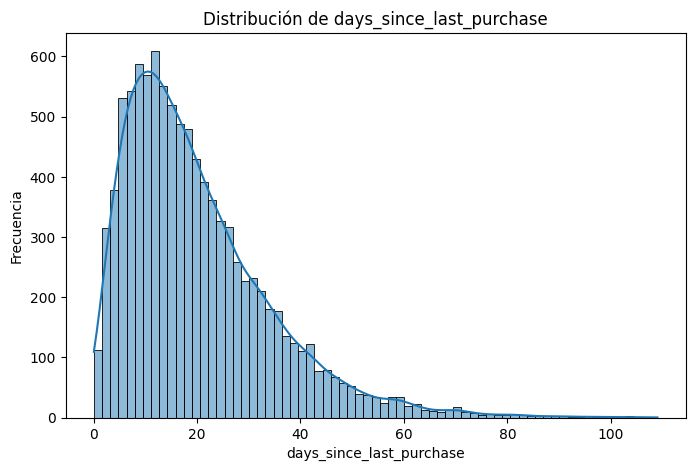

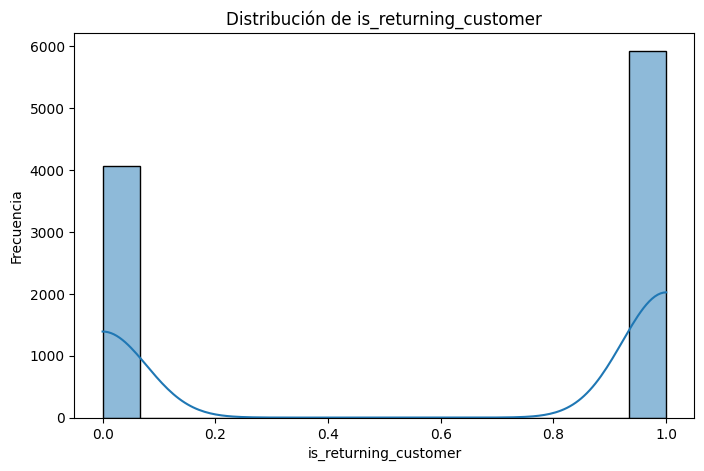

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVisualizando distribuciones de frecuencia con histogramas:")
for col in numeric_vars.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

5. Analice si las variables siguen una distribución normal

Utilice `stats.shapiro(sample)` para realizar prueba de normalidad y analice valores p

In [28]:
import scipy.stats as stats

print("\nAnálisis de Normalidad (Shapiro):")
for col in numeric_vars.columns:
    sample_size = min(5000, len(df[col]))
    sample = df[col].sample(n=sample_size, random_state=42)

    stat, p_value = stats.shapiro(sample)

    print(f"\n  Variable: {col}")
    print(f"    Estadístico W: {stat:.4f}")
    print(f"    Valor p: {p_value:.4f}")

    if p_value > 0.05:
        print("    Interpretación: No se puede rechazar la hipótesis nula. La muestra parece seguir una distribución normal.")
    else:
        print("    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.")

print("\nConclusión: Un valor p menor a un nivel de significancia (comúnmente 0.05) indica que la distribución de la variable difiere significativamente de una distribución normal.")


Análisis de Normalidad (Shapiro):

  Variable: transaction_id
    Estadístico W: 0.9539
    Valor p: 0.0000
    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.

  Variable: customer_id
    Estadístico W: 0.9515
    Valor p: 0.0000
    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.

  Variable: price
    Estadístico W: 0.9517
    Valor p: 0.0000
    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.

  Variable: quantity
    Estadístico W: 0.9211
    Valor p: 0.0000
    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.

  Variable: discount_applied
    Estadístico W: 0.5759
    Valor p: 0.0000
    Interpretación: Se rechaza la hipótesis nula. La muestra no parece seguir una distribución normal.

  Variable: page_views_before_purchase
    Estadístico W: 0.9403
    Valor p: 0.0000
    Interp